In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("miadul/credit-card-fraud-detection-dataset")

print("Path to dataset files:", path)

C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\ASUS\.cache\kagglehub\datasets\miadul\credit-card-fraud-detection-dataset\versions\1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

import shap
from lime.lime_tabular import LimeTabularExplainer

In [6]:
df =  pd.read_csv("D:\\fraud_detect_ML_Model\\credit_card_fraud_10k.csv")
df

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0


In [7]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [8]:
df.isnull()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [10]:
print(df["is_fraud"].value_counts())

is_fraud
0    9849
1     151
Name: count, dtype: int64


In [11]:
features = [
    "transaction_id",
    "amount",
    "transaction_hour",
    "merchant_category",
    "foreign_transaction",
    "device_trust_score",
    "velocity_last_24h"
]

x = df[features]
y = df["is_fraud"]

In [12]:
x = pd.get_dummies(x)

le = LabelEncoder()
y_encoded = le.fit_transform(y)


pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

# Train-Test Split
x_train, x_test, y_train, y_test = train_test_split(
    x_pca,
    y_encoded,
    test_size=0.2,
    random_state=42
)

# Train Model
model = XGBClassifier()
model.fit(x_train, y_train)

# Testing
y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

# New Transaction Detection
new_transaction = pd.DataFrame({
    "transaction_id":[10000],
    "amount":[1000],
    "transaction_hour":[23],
    "merchant_category":["Electronics"],
    "foreign_transaction":[1],
    "device_trust_score":[2],
    "velocity_last_24h":[5]
})

new_transaction_processed = new_transaction.reindex(columns=x.columns, fill_value=0)

new_transaction_pca = pca.transform(new_transaction_processed)

prediction = model.predict(new_transaction_pca)

if prediction[0] == 1:
    print("Fraud Transaction Detected!")
else:
    print("Not Fraud Transaction")

Accuracy: 0.9845
Not Fraud Transaction


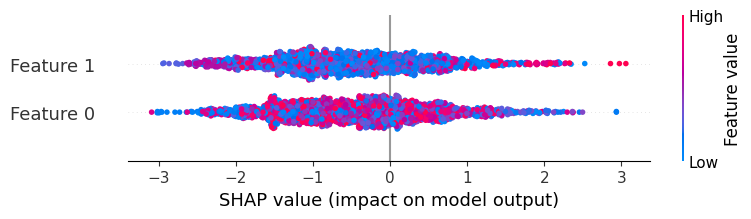

In [13]:
explainer = shap.Explainer(model)
shap_values = explainer(x_test)

shap.summary_plot(shap_values, x_test)

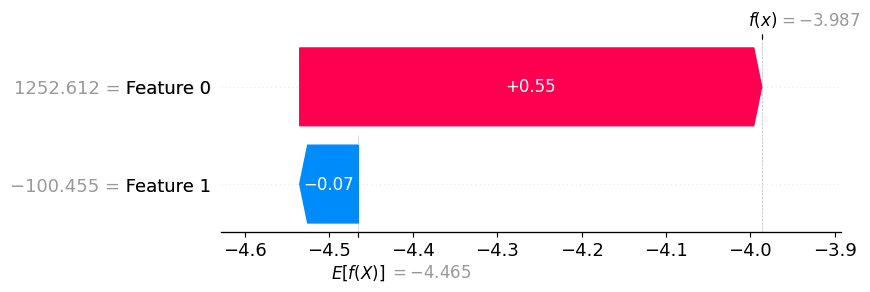

In [14]:
shap.plots.waterfall(shap_values[0])

In [29]:
explainer_lime = LimeTabularExplainer(
    training_data=np.array(x_train),
    feature_names=["PC1", "PC2"],
    class_names=["Not Fraud", "Fraud"],
    mode="classification"
)

i = 0

exp = explainer_lime.explain_instance(
    data_row=x_test[i],
    predict_fn=model.predict_proba
)

display(HTML(exp.as_html()))

print(exp.as_list())

[('-125.82 < PC2 <= -54.19', -0.0029577358802195253), ('14.07 < PC1 <= 2504.68', 0.0008058700942929497)]


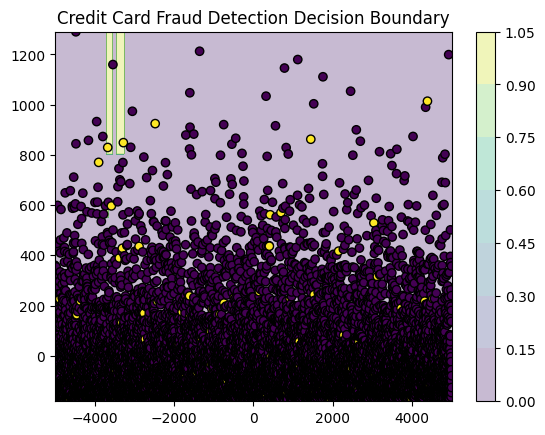

In [30]:

xx, yy = np.meshgrid(
    np.arange(x_pca[:,0].min()-1, x_pca[:,0].max()+1, 1),
    np.arange(x_pca[:,1].min()-1, x_pca[:,1].max()+1, 1)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)

plt.colorbar()

plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=y_encoded,
    edgecolors='k'
)

plt.title("Credit Card Fraud Detection Decision Boundary")

plt.show()